# Resumo Capítulo 2 - Projeto de ML de Ponta a Ponta

## Fluxo do projeto:

Antes de darmos início ao nosso projeto, primeiro vamos discorrer sobre como será o fluxo do nosso projeto. Ele será dividido em 8 passos:

    - Analisar o panorama geral do problema
    - Obter os dados
    - Visualizar os dados para obter insights
    - Preparar os dados (Limpeza e engenharia de features)
    - Selecionar e treinar o modelo
    - Aperfeiçoar o modelo
    - Apresentar o modelo
    - Subir em produção, monitorar e fazer manutenções

## Objetivo do projeto:

Nosso objetivo será de treinar um modelo que consiga prever o preço médio dos imóveis de uma região da Califórnia a partir dos dados de um censo de 1990, o conjunto de dados possui características como população, renda média, dentre outras, e a partir dessas devemos prever o preço médio de um imóvel.

Antes de começarmos a selecionar o modelo e a medida de desempenho precisamos entender o que o nosso cliente quer, não apenas entregar um modelo, para isso precisamos saber como o nosso cliente vai usar o modelo e como ele será beneficiado(acho um pouco invasivo essa pergunta, porém não custa citar :)), além disso precisamos saber a solução atual(se houver) para que possamos utilizá-la como um guia, além de analisarmos os pontos onde são necessárias melhorias.

Nosso cliente disse que as informações obtidas a partir do modelo (podemos chamar essas informações de **sinais**, termo baseado na teoria da informação de Shannon) que iremos criar irá alimentar um data store, o qual irá fornecer dados para um modelo de análise financeira, atualmente os preços médios dos imóveis são definidos manualmente por especialistas, seguindo várias regras complexas, porém esses preços médios estão sendo definidos um pouco abaixo do que deveriam, causando a diminuição no faturamento da empresa, visto que as análises financeiras acabam prejudicadas.

## Pipeline de dados:

Antes de definirmos o que usar, vamos primeiro entender o que é um pipeline de dados. Um pipeline de dados define como diferentes componentes irão se comportar no processamento de dados, no caso do nosso projeto, nosso modelo é um componente, assim como o data store e o modelo de análise financeira.

Cada modelo funciona de forma assíncrona e de maneira independente, de modo que se uma parte do sistema parar de funcionar as outras continuaram funcionando com as informações que têm.

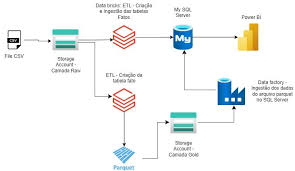

Porém não é porque eles continuam funcionando que não precisamos monitorar, lembre-se, "Entra lixo, sai lixo", se os modelos começarem a ser alimentados com os mesmos dados, ou dados que não refletem a realidade, eles irão começar a ter uma queda de desempenho, como um professor meu fala, o fumo é grande.

## Definindo o que iremos usar:

Para começar, pense um pouco, que tipo de aprendizado será utilizado, supervisionado, não supervisionado ou por reforço? Que tipo de tarefa estamos realizando, regressão ou classificação? Iremos utilizar técnicas de aprendizado em batch ou online? Antes de ver o próximo parágrafo responda essas perguntas, com a base que foi obtida a partir do capítulo anterior você já é capaz de responder essas perguntas, se desafie!

O nosso problema utilizará um algoritmo de aprendizado supervisionado, visto que os dados que iremos utilizar estão rotulados com os preços médios por região, como queremos prever um valor numérico vamos realizar uma tarefa de regressão, e indo um pouco além, iremos utilizar um modelo de regressão múltipla, pois estamos utilizando mais de uma característica para prever nosso valor, e de regressão univariada, pois queremos prever apenas um valor, por fim, como não há a necessidade de atualização em tempo real do modelo e temos recursos computacionais o suficiente para fazer o treinamento com todos os dados de uma vez, vamos utilizar técnicas de aprendizado em batch.

Nota => Caso nosso conjunto de dados fosse muito grande, poderíamos distribuir o treino em vários servidores e cada um realizar técnicas de aprendizado em batch, sendo possível de fazer isso a partir da técnica de **MapReduce**. Ou poderíamos utilizar uma técnica de aprendizado online.

## Escolhendo a medida de desempenho:

Para começar vamos escolher uma medida de desempenho, para problemas de regressão uma das medidas mais usadas é a **Raiz do Erro Quadrático Médio** ou **RMSE**, definida matemáticamente por:

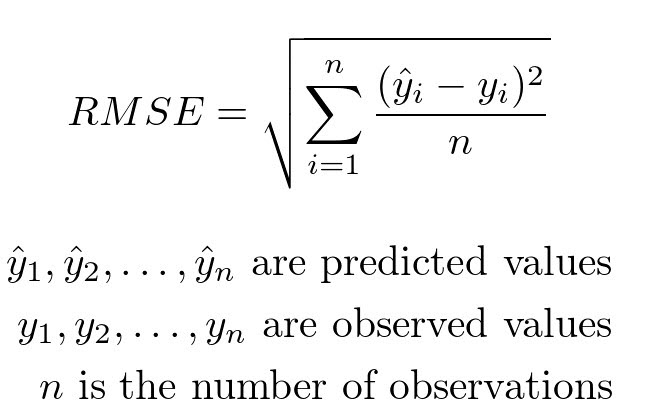

chamamos o y^ de **hipótese h(x)**, que nada mais representa o valor da função de previsão utilizada no modelo.

Dizemos que essa métrica utiliza a **norma euclidiana**, utilizada para calcular a distância entre dois vetores, então podemos definir a fórmula da seguinte maneira:

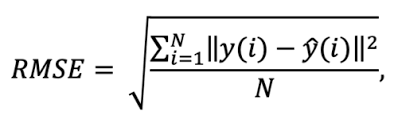

A RMSE é uma métrica utilizada quando outliers são raros no conjunto de dados, pois por elevar o erro ao quadrado ela se torna mais sensível a erros grandes, ou seja, outliers, desse modo, se o nosso dataset possuísse muitos outliers, não conseguiríamos saber se o valor alto do erro seria a soma de muitos erros pequenos ou a soma de poucos erros grandes.Para contornar essa situação, poderíamos utilizar outra métrica muito usada em tarefas de regressão, o **Erro Médio Absoluto** ou **MAE**.

A métrica MAE utiliza a **norma de manhattan** para calcular a distância entre os vetores de valores de previsão e os vetores de valores reais, enquanto a norma euclidiana utiliza o quadrado da distância, essa norma utiliza o módulo da distância:

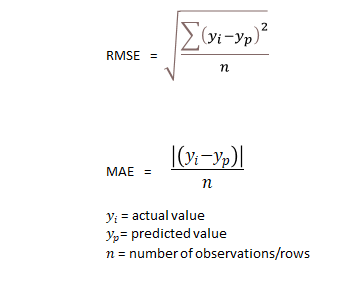

Por utilizar o módulo essa métrica é muito utilizada quando o conjunto de dados possui muitos ouliers, já que ela é menos sensível a eles. 

Agora vamos colocar as mãos na massa e começar a programar

## Instalando as bibliotecas:

Para o nosso projeto iremos utilizar as seguintes bibliotecas

- Matplotlib: Para visualização dos dados
- Numpy: Base para as outras bibliotecas e para operações matriciais
- Pandas: Para manipulação dos dados
- Scipy: Biblioteca com base no numpy a qual possui vários algoritmos de otimização
- Scikit-learn: Biblioteca com modelos de ML

Para fazer a instalação das bibliotecas vamos utilizar o instalador de pacotes do python o `pip`, executando o seguinte comando no seu python notebook:

`pip install -U matplotlib scipy scikit-learn pandas numpy``

## Obtendo os dados:

Geralmente em projetos reais de ML você irá acessar os dados de um banco de dados relacional ou não relacional, o qual necessita de tokens e autorização para fazê-lo. Para evitar essa burocracia, vamos já importar os dados prontos precisando apenas extrair para obter o csv.

Para isso iremos criar um script para automatizar esse processo, assim nós não precisaremos toda vez ir no site fazer a instalação e extrair manualmente, isso é muito útil em situações em que você terá que treinar seu modelo consistente. O script seguirá o seguinte fluxo:

- Cria os diretórios datasets e housing.
- Faz a requisição para obter os dados.
- Faz a extração dos dados.
- Armazena o csv no diretório housing.

O script está logo abaixo, uma dica, não se preocupe em decorar códigos agora, se preocupe em entender o processo, o passo a passo, já que com a experiência os códigos irão ficar na sua cabeça, sem contar que hoje em dia temos a IA para nós ajudar, e se entendermos o que queremos fazer a IA é uma das nossas melhores aliadas.

```python
import os
import tarfile
import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url = HOUSING_URL, housing_path = HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    
fetch_housing_data()
```

Feito isso agora vamos ler os dados utilizando a biblioteca pandas:

```python
import pandas as pd

def load_housing_data(housing_path = HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housind = load_housing_data()
```

Agora podemos começar a analisar a estrutura dos dados e entender as características e a variável alvo do dataset.

## Analisando a estrutura do dataset:

Primeira coisa que vamos fazer é visualizar as 5 primeiras linhas do nosso dataset, apenas para dar uma olhada, para isso vamos utilizar o método `df.head()` o qual irá exibir as 5 primeiras linhas:

```python
housing.head()
```

Não irei colocar o retorno dos métodos nesse arquivo, os retornos estarão no arquivo de implementação do projeto, e também quero que você, a medida que eu vou escrevendo código, também escreva e tente entender cada passo, se quiser você também pode explorar a biblioteca pandas sozinho, sinta-se a vontade.

A partir das 5 primeiras linhas percebemos que todas as variáveis exceto a variável `ocean_proximity` são **variáveis quantitativas**, ou seja, são variáveis que guardam valores numéricos, nesse âmbito podemos classificar elas em dois tipos:

- **Variáveis Quantitativas Discretas**: Recebem valores inteiros, como a variável que expressa a idade do imóvel.

- **Variáveis Quantitativas Contínuas**: Recebem valores floats, como a variável que expressa a renda mensal da região.

Cada tipo possuí maneiras específicas de se visualizar e manipular, por ora não iremos entrar no assunto, porém fique ciente disso.

Vamos analisar do que se trata a variável `ocean_proximity`, analisando os valores únicos dela, para isso iremos utilizar o método `df[variável].unique()`, que irá me retornar os valores únicos da variável:

```python
housing['ocean_proximity'].unique()
```

Analisando o retorno percebemos que a variável possui 5 valores únicos, os quais podemos considerar como categorias, ou classes, desse modo classificaremos essa variável como **variável categórica**.

Agora vamos analisar algumas informações gerais do dataset como contagem de registros, valores nulos e tipos das variáveis, para isso vamos executar o método `df.info()`:

```python
housing.info()
```

Analisando o retorno vemos que temos 20640 registros no total, com apenas a variável `total_bedrooms` possuindo valores faltantes, vamos lidar com isso depois, além disso vemos que apenas a variável `ocean_proximity` é do tipo string e todas as outras são do tipo float64, chamamos as variáveis que não armazenam valores numéricos de **Variáveis Qualitativas**, as quais irão representar uma qualidade que não pode ser medida em números, nesse âmbito temos os seguintes tipos:

- **Variáveis Qualitativas Nominais**: Armazenam valores que não possuem uma ordem ou hierarquia. Ex: Nome.

- **Variáveis Qualitativas Ordinais**: Armazenam valores que possuem uma ordem ou hierarquia. Ex: Classe Social.

Cada tipo de variável possuem diferentes maneiras de se trabalhar que serão abordadas futuramente.

*Guarde o seguinte, existem para visualizar e manipular Variáveis Qualitativas e Quantitativas serão utilizados diferentes tipos de gráficos e manipulação para cada tipo, por exemplo, se queremos analisar a frequência de cada classe da Variável Qualitativa podemos usar um gráfico de barras enquanto utilizaríamos um histograma para as Quantitativas para analisar a frequência de diferentes faixas de valores.*

Vamos analisar as variáveis numéricas, queremos ver valores que resumem cada variável e que possam nós ajudar a analisar a variabilidade dos dados de cada variável, chamamos as medidas que resumem de **Medidas de Posição**:

- Média: Retorna o valor médio da variável.

- Mediana: Retorna o valor central dos registros.

- Moda: Retorna o valor mais frequente.

Segue abaixo as fórmulas para calcular cada uma:

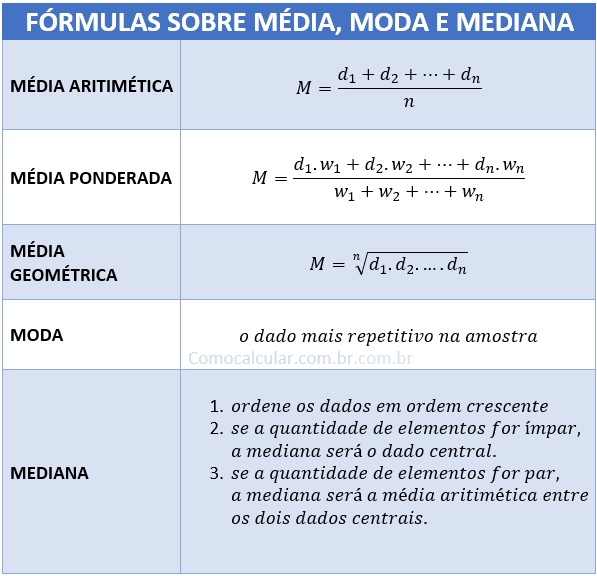

As medidas que resumem a variabilidade dos dados são chamadas de **Medidas de Dispersão**:

- Desvio Médio, Variância: Retornam um valor que representa o erro que haveria caso substituíssemos Xi pela média.

- Desvio Padrão: Raiz da variância.

Todos esses valores calculam o erro médio em relação à média. Segue abaixo as fórmulas matemáticas para cada medida:

$$dm(x) = \frac{1}{n} \sum_{i=1}^{n} | x_i - \bar x\ |$$

$$ var(x) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar x\ )^2 $$

$$ dp(x) = \sqrt{var(x)} $$

$$ \bar x\ = média $$

*Nota: Quando analisamos o histogramas de uma variável numérica e obtemos uma distribuição em formato de sino, dizemos que 68% dos dados estão entre [média - desvio padrão, média + desvio padrão], 95% dos dados estão entre [média - 2 * desvio padrão, média + 2 * desvio padrão] e 98,7% dos dados estão entre [média - 3 * desvio padrão, média + 3 * desvio padrão].*

Por fim, vamos plotar um histograma para analisar a distribuição das variáveis numéricas, para isso vamos usar o matplotlib e o método `df.hist()`

```python
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20, 15))
plt.show()
```

A partir dos histogramas vemos que algumas variáveis possuem o que chamamos de *tail-heavy* ou *cauda longa* se estendendo mais à diretia da média do que à esquerda, isso pode ser um problema para a detecção de padrões do modelo, resolveremos isso depois.

Antes de darmos prosseguimento na visualização dos dados, precisamos separar o nosso conjunto de dados em dois, o conjunto de treino e o conjunto de teste.